In [36]:
import pandas as pd

In [37]:
df = pd.read_parquet(r"C:\Users\mnapo\Desktop\IBKR Stuff\ALL_DATA\tick_events\GBP-USD\20260528\ticks_GBP-USD_20260528_095337.parquet")

In [38]:
df

,timestamp,tick_field,tick_value,bid,ask,bid_size,ask_size,exchange
0,2026-05-28 09:53:39.516360-04:00,bid,1.341950e+00,1.34195,1.34552,1000000.0,4000000.0,IDEALPRO
1,2026-05-28 09:53:39.523360-04:00,ask_size,1.000000e+06,1.34195,1.34201,2000000.0,1000000.0,IDEALPRO
2,2026-05-28 09:53:39.524359-04:00,ask_size,1.000000e+06,1.34195,1.34201,2000000.0,1000000.0,IDEALPRO
3,2026-05-28 09:53:41.020980-04:00,bid_size,1.000000e+06,1.34195,1.34201,1000000.0,1000000.0,IDEALPRO
4,2026-05-28 09:53:41.278001-04:00,bid_size,2.000000e+06,1.34195,1.34201,2000000.0,1000000.0,IDEALPRO
...,...,...,...,...,...,...,...,...
180592,2026-05-28 23:51:19.985063-04:00,bid,1.343240e+00,1.34324,1.34324,1000000.0,1000000.0,IDEALPRO
180593,2026-05-28 23:51:19.986065-04:00,ask,1.343270e+00,1.34324,1.34327,1000000.0,1000000.0,IDEALPRO
180594,2026-05-28 23:51:19.987064-04:00,ask_size,2.000000e+06,1.34324,1.34327,1000000.0,2000000.0,IDEALPRO
180595,2026-05-28 23:51:20.289902-04:00,ask_size,1.000000e+06,1.34324,1.34327,1000000.0,1000000.0,IDEALPRO


In [39]:
df = df.drop_duplicates(subset=["timestamp"], keep="last").reset_index(drop=True)
df["midprice"] = (df["bid"] + df["ask"]) / 2

df["microprice"] = (
    df["ask"] * df["bid_size"] + df["bid"] * df["ask_size"]
) / (df["bid_size"] + df["ask_size"])
df

,timestamp,tick_field,tick_value,bid,ask,bid_size,ask_size,exchange,midprice,microprice
0,2026-05-28 09:53:39.516360-04:00,bid,1.341950e+00,1.34195,1.34552,1000000.0,4000000.0,IDEALPRO,1.343735,1.342664
1,2026-05-28 09:53:39.523360-04:00,ask_size,1.000000e+06,1.34195,1.34201,2000000.0,1000000.0,IDEALPRO,1.341980,1.341990
2,2026-05-28 09:53:39.524359-04:00,ask_size,1.000000e+06,1.34195,1.34201,2000000.0,1000000.0,IDEALPRO,1.341980,1.341990
3,2026-05-28 09:53:41.020980-04:00,bid_size,1.000000e+06,1.34195,1.34201,1000000.0,1000000.0,IDEALPRO,1.341980,1.341980
4,2026-05-28 09:53:41.278001-04:00,bid_size,2.000000e+06,1.34195,1.34201,2000000.0,1000000.0,IDEALPRO,1.341980,1.341990
...,...,...,...,...,...,...,...,...,...,...
180592,2026-05-28 23:51:19.985063-04:00,bid,1.343240e+00,1.34324,1.34324,1000000.0,1000000.0,IDEALPRO,1.343240,1.343240
180593,2026-05-28 23:51:19.986065-04:00,ask,1.343270e+00,1.34324,1.34327,1000000.0,1000000.0,IDEALPRO,1.343255,1.343255
180594,2026-05-28 23:51:19.987064-04:00,ask_size,2.000000e+06,1.34324,1.34327,1000000.0,2000000.0,IDEALPRO,1.343255,1.343250
180595,2026-05-28 23:51:20.289902-04:00,ask_size,1.000000e+06,1.34324,1.34327,1000000.0,1000000.0,IDEALPRO,1.343255,1.343255


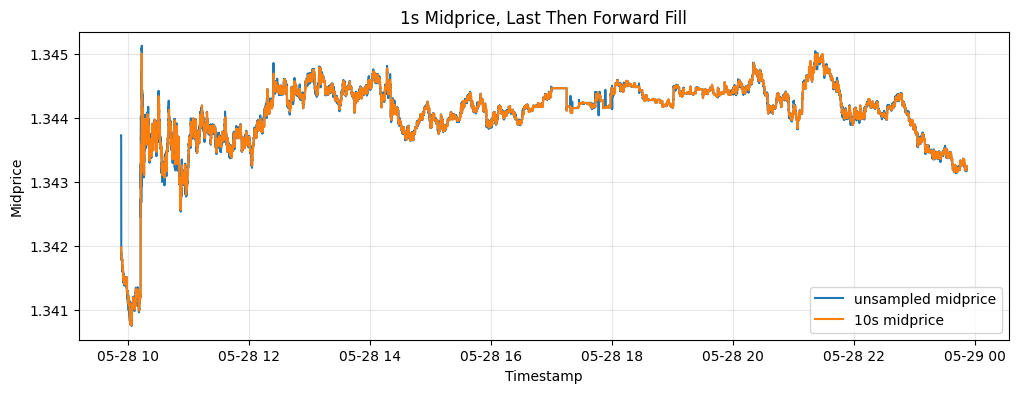

In [40]:
import matplotlib.pyplot as plt

df_10s = (
    df.set_index("timestamp")
      .sort_index()
      .resample("10s", label="right", closed="right")
      .last()
      .ffill()
)

plt.figure(figsize=(12, 4))
plt.step(df["timestamp"], df["midprice"], where="post", label="unsampled midprice")
plt.step(df_10s.index, df_10s["midprice"], where="post", label="10s midprice")
plt.xlabel("Timestamp")
plt.ylabel("Midprice")
plt.title("1s Midprice, Last Then Forward Fill")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [41]:
print(df.columns)

Index(['timestamp', 'tick_field', 'tick_value', 'bid', 'ask', 'bid_size',
       'ask_size', 'exchange', 'midprice', 'microprice'],
      dtype='str')


In [45]:
import numpy as np
import pandas as pd

# choose price used for returns / MTM
price_col = "midprice"   # or "microprice"

df = df.sort_values("timestamp").copy()

# log returns
df["log_ret"] = np.log(df[price_col]).diff()

# trade rule:
# if log return > 0: sell 1mm GBPUSD => short 1mm GBP
# if log return < 0: buy 1mm GBPUSD  => long 1mm GBP
trade_size_gbp = 1_000_000

df["trade_gbp"] = np.where(
    df["log_ret"] > np.log(0.0001), -trade_size_gbp,
    np.where(df["log_ret"] < 0, trade_size_gbp, 0)
)

# position AFTER each signal/trade
df["pos_gbp"] = df["trade_gbp"].cumsum()

# mark-to-market PnL in USD from GBP position
# use previous position over the price move to avoid lookahead
df["pnl_usd"] = df["pos_gbp"].shift(1).fillna(0) * df[price_col].diff().fillna(0)

df["cum_pnl_usd"] = df["pnl_usd"].cumsum()

print(df["cum_pnl_usd"].iloc[-1])

109773569.99998459


In [48]:
df["exec_price"] = np.where(
    df["trade_gbp"] > 0, df["ask"],   # buying GBP pays ask
    np.where(df["trade_gbp"] < 0, df["bid"], np.nan)  # selling GBP hits bid
)

df["cash_usd"] = -(df["trade_gbp"] * df["exec_price"]).fillna(0).cumsum()
df["pos_gbp"] = df["trade_gbp"].cumsum()

df["mtm_value_usd"] = df["pos_gbp"] * df[price_col]
df["cum_pnl_usd"] = df["cash_usd"] + df["mtm_value_usd"]

print(df["cum_pnl_usd"].iloc[-1])

105858909.99996948


In [49]:
df

,timestamp,tick_field,tick_value,bid,ask,bid_size,ask_size,exchange,midprice,microprice,log_ret,trade_gbp,pos_gbp,pnl_usd,cum_pnl_usd,exec_price,cash_usd,mtm_value_usd
0,2026-05-28 09:53:39.516360-04:00,bid,1.341950e+00,1.34195,1.34552,1000000.0,4000000.0,IDEALPRO,1.343735,1.342664,NaN,0,0,0.000000e+00,0.000000e+00,NaN,-0.000000e+00,0.000000e+00
1,2026-05-28 09:53:39.523360-04:00,ask_size,1.000000e+06,1.34195,1.34201,2000000.0,1000000.0,IDEALPRO,1.341980,1.341990,-0.001307,-1000000,-1000000,-0.000000e+00,-3.000000e+01,1.34195,1.341950e+06,-1.341980e+06
2,2026-05-28 09:53:39.524359-04:00,ask_size,1.000000e+06,1.34195,1.34201,2000000.0,1000000.0,IDEALPRO,1.341980,1.341990,0.000000,-1000000,-2000000,-0.000000e+00,-6.000000e+01,1.34195,2.683900e+06,-2.683960e+06
3,2026-05-28 09:53:41.020980-04:00,bid_size,1.000000e+06,1.34195,1.34201,1000000.0,1000000.0,IDEALPRO,1.341980,1.341980,0.000000,-1000000,-3000000,-0.000000e+00,-9.000000e+01,1.34195,4.025850e+06,-4.025940e+06
4,2026-05-28 09:53:41.278001-04:00,bid_size,2.000000e+06,1.34195,1.34201,2000000.0,1000000.0,IDEALPRO,1.341980,1.341990,0.000000,-1000000,-4000000,-0.000000e+00,-1.200000e+02,1.34195,5.367800e+06,-5.367920e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180592,2026-05-28 23:51:19.985063-04:00,bid,1.343240e+00,1.34324,1.34324,1000000.0,1000000.0,IDEALPRO,1.343240,1.343240,0.000004,-1000000,-180592000000,-9.029550e+05,1.085678e+08,1.34324,2.426870e+11,-2.425784e+11
180593,2026-05-28 23:51:19.986065-04:00,ask,1.343270e+00,1.34324,1.34327,1000000.0,1000000.0,IDEALPRO,1.343255,1.343255,0.000011,-1000000,-180593000000,-2.708880e+06,1.058590e+08,1.34324,2.426883e+11,-2.425825e+11
180594,2026-05-28 23:51:19.987064-04:00,ask_size,2.000000e+06,1.34324,1.34327,1000000.0,2000000.0,IDEALPRO,1.343255,1.343250,0.000000,-1000000,-180594000000,-0.000000e+00,1.058589e+08,1.34324,2.426897e+11,-2.425838e+11
180595,2026-05-28 23:51:20.289902-04:00,ask_size,1.000000e+06,1.34324,1.34327,1000000.0,1000000.0,IDEALPRO,1.343255,1.343255,0.000000,-1000000,-180595000000,-0.000000e+00,1.058589e+08,1.34324,2.426910e+11,-2.425851e+11


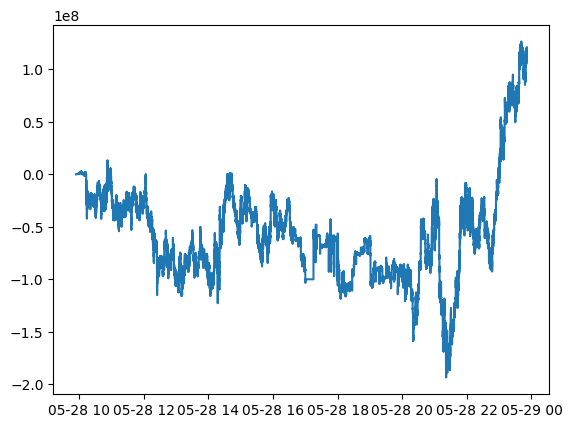

In [50]:
plt.step(df["timestamp"], df["cum_pnl_usd"], where="post")